In [ ]:
# ============================================================
#  Dankmemes Humor Classification System
#  Using Kaggle dataset: gmorinan/memes-classified-and-labelled
#  - Loads metadata.csv (image, label)
#  - Matches to image files
#  - Train/Val/Test split
#  - ResNet18 + Early Stopping
#  - Final Test Evaluation
#  - Single-image prediction helper
# ============================================================

!pip install kagglehub -q

import os
import time
import copy

import kagglehub
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.io import read_image
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# 1. Download dataset
# -----------------------------
print("Downloading Kaggle dataset: gmorinan/memes-classified-and-labelled ...")
dataset_path = kagglehub.dataset_download("gmorinan/memes-classified-and-labelled")
print("Dataset downloaded to:", dataset_path)

print("\nSome files in dataset_path:")
for i, f in enumerate(os.listdir(dataset_path)[:20]):
    print(" ", f)
print("...(truncated)\n")

# -----------------------------
# 2. Find images + CSV file
# -----------------------------
SUPPORTED_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff")

all_files = []
for dirpath, dirnames, filenames in os.walk(dataset_path):
    for f in filenames:
        all_files.append(os.path.join(dirpath, f))

image_files = [p for p in all_files if p.lower().endswith(SUPPORTED_EXTS)]
csv_files   = [p for p in all_files if p.lower().endswith(".csv")]

print(f"Found {len(image_files)} image files.")
print("CSV files found:", csv_files)

if len(image_files) == 0:
    raise RuntimeError("❌ No image files found in the Kaggle dataset path.")

if len(csv_files) == 0:
    raise RuntimeError("❌ No CSV file found in the dataset. Expected metadata.csv.")

csv_path = csv_files[0]
print("\nUsing CSV file:", csv_path)

df = pd.read_csv(csv_path)
print("\nCSV columns:", list(df.columns))
print("First 5 rows:")
print(df.head())

# -------------------------------------------------------
# 3. Decide which columns are image filenames and labels
# -------------------------------------------------------
possible_image_cols = ["image", "img", "filename", "file", "meme", "meme_image", "image_name"]
possible_label_cols = ["label", "class", "category", "meme_type", "target"]

def pick_col(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

IMAGE_COL = pick_col(possible_image_cols, df.columns)
LABEL_COL = pick_col(possible_label_cols, df.columns)

if IMAGE_COL is None or LABEL_COL is None:
    raise RuntimeError(
        "❌ Could not automatically detect image/label columns.\n"
        f"CSV columns are: {list(df.columns)}\n"
        "Please set IMAGE_COL and LABEL_COL manually."
    )

print(f"\nUsing IMAGE_COL = {IMAGE_COL}")
print(f"Using LABEL_COL = {LABEL_COL}")

df = df[[IMAGE_COL, LABEL_COL]].dropna()
df = df.rename(columns={IMAGE_COL: "image_name", LABEL_COL: "label"})

# -----------------------------
# 4. Map CSV image names to real file paths
# -----------------------------
path_by_name = {}
path_by_stem = {}

for p in image_files:
    base = os.path.basename(p)
    path_by_name[base] = p
    stem = os.path.splitext(base)[0]
    path_by_stem[stem] = p

img_paths = []
labels = []

for _, row in df.iterrows():
    img_id = str(row["image_name"]).strip()
    lbl = row["label"]

    candidate_path = None

    if img_id in path_by_name:
        candidate_path = path_by_name[img_id]
    else:
        stem = os.path.splitext(img_id)[0]
        if stem in path_by_stem:
            candidate_path = path_by_stem[stem]

    if candidate_path is not None:
        img_paths.append(candidate_path)
        labels.append(lbl)

print(f"\nMatched {len(img_paths)} CSV rows to existing image files.")

if len(img_paths) == 0:
    raise RuntimeError(
        "❌ Could not match any CSV rows to image files.\n"
        "Check whether CSV image names correspond to actual filenames."
    )

df_pairs = pd.DataFrame({
    "path": img_paths,
    "label": labels
})

print("\nLabel distribution (raw) (top 10):")
print(df_pairs["label"].value_counts().head(10))

# Encode labels
unique_labels = sorted(df_pairs["label"].unique().tolist())
label_to_id = {lbl: i for i, lbl in enumerate(unique_labels)}
id_to_label = {i: lbl for lbl, i in label_to_id.items()}

df_pairs["label_id"] = df_pairs["label"].map(label_to_id)

num_classes = len(unique_labels)
print("\nClasses:", unique_labels)
print("Number of classes:", num_classes)
print("Total matched samples:", len(df_pairs))

# -----------------------------
# 5. Train/Val/Test split
# -----------------------------
train_df, temp_df = train_test_split(
    df_pairs,
    test_size=0.3,
    random_state=42,
    stratify=df_pairs["label_id"]
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# -----------------------------
# 6. PyTorch Dataset
# -----------------------------
class MemeImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df["path"].values
        self.labels = df["label_id"].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]
        image = read_image(img_path).float() / 255.0  # [C,H,W] in [0,1]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda im: im.convert("RGB")),  # ensure 3 channels
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda im: im.convert("RGB")),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = MemeImageDataset(train_df, transform=train_transform)
val_dataset   = MemeImageDataset(val_df,   transform=eval_transform)
test_dataset  = MemeImageDataset(test_df,  transform=eval_transform)

BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
PATIENCE = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", DEVICE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 7. ResNet18 model
# -----------------------------
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# -----------------------------
# 8. Helper: evaluation
# -----------------------------
def eval_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE)
            lbls = lbls.to(DEVICE)

            out = model(imgs)
            loss = criterion(out, lbls)
            preds = out.argmax(1)
            acc = (preds == lbls).float().mean().item()

            total_loss += loss.item()
            total_acc += acc
            n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

# -----------------------------
# 9. Training loop with early stopping
# -----------------------------
best_val_loss = float("inf")
best_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

print("\n🚀 Starting training (Dankmemes Humor Classification System)...")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 40)

    model.train()
    running_loss = 0.0
    n_batches = 0

    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    train_loss = running_loss / n_batches
    val_loss, val_acc = eval_model(model, val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print("✅ Validation improved → saving best weights.")
    else:
        epochs_no_improve += 1
        print(f"No improvement in val loss for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= PATIENCE:
            print("⏹ Early stopping triggered.")
            break

# -----------------------------
# 10. Save best model
# -----------------------------
model.load_state_dict(best_wts)
os.makedirs("checkpoints", exist_ok=True)
model_path = "checkpoints/dankmemes_humor_resnet18.pth"
torch.save(model.state_dict(), model_path)
print("\n💾 Best model saved at:", model_path)

# -----------------------------
# 11. Final Test Evaluation
# -----------------------------
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        out = model(imgs)
        preds = out.argmax(1)

        all_labels.extend(lbls.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("\n=== TEST SET RESULTS ===")
print(confusion_matrix(all_labels, all_preds))
print(classification_report(
    all_labels,
    all_preds,
    target_names=[id_to_label[i] for i in range(num_classes)]
))

print("\n🎉 Dankmemes Humor Classification System finished successfully.")

# -----------------------------
# 12. Single-image prediction helper
# -----------------------------
import torchvision.transforms as T
from PIL import Image

predict_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def predict_meme(image_path):
    """
    Predict meme template label for a single image.
    """
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = predict_transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        pred_id = torch.argmax(probs).item()

    pred_label = id_to_label[pred_id]
    pred_prob = probs[pred_id].item()
    print(f"Predicted class: {pred_label} (p={pred_prob:.4f})")
    return pred_label, pred_prob

# Example usage after training:
# sample_path = train_df.iloc[0]["path"]
# predict_meme(sample_path)


Using Colab cache for faster access to the 'memes-classified-and-labelled' dataset.
Dataset downloaded to: /kaggle/input/memes-classified-and-labelled

Some files in dataset_path:
  valid
  metadata.csv
  train
...(truncated)

Found 5716 image files.
CSV files found: ['/kaggle/input/memes-classified-and-labelled/metadata.csv']

Using CSV file: /kaggle/input/memes-classified-and-labelled/metadata.csv

CSV columns: ['image', 'label', 'dataset', 'section', 'timestamp', 'url', 'domain', 'score', 'ncoms', 'gilded', 'nxpst', 'idRdt']
First 5 rows:
                    image                        label dataset  \
0  001i5ooagzm11_redt.jpg   that_wasnt_very_cash_money   valid   
1  00bppf96ge801_redt.jpg  of_course_i_know_him_hes_me   valid   
2  00gvjdi9oe421_redt.jpg                  rewind_time   valid   
3  00m3fnr54kc11_redt.jpg                   how_old_is   train   
4  00mnypugvw021_redt.jpg                 sisters_name   valid   

            section     timestamp                      

100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]



🚀 Starting training (Dankmemes Humor Classification System)...

Epoch 1/10
----------------------------------------
Train Loss: 1.8701
Val   Loss: 0.2838 | Val Acc: 0.9919
✅ Validation improved → saving best weights.

Epoch 2/10
----------------------------------------
Train Loss: 0.2501
Val   Loss: 0.1080 | Val Acc: 0.9954
✅ Validation improved → saving best weights.

Epoch 3/10
----------------------------------------
Train Loss: 0.1220
Val   Loss: 0.0662 | Val Acc: 0.9965
✅ Validation improved → saving best weights.

Epoch 4/10
----------------------------------------
Train Loss: 0.0762
Val   Loss: 0.0504 | Val Acc: 0.9954
✅ Validation improved → saving best weights.

Epoch 5/10
----------------------------------------
Train Loss: 0.0640
Val   Loss: 0.0441 | Val Acc: 0.9954
✅ Validation improved → saving best weights.

Epoch 6/10
----------------------------------------
Train Loss: 0.0546
Val   Loss: 0.0397 | Val Acc: 0.9954
✅ Validation improved → saving best weights.

Epoch 7/10


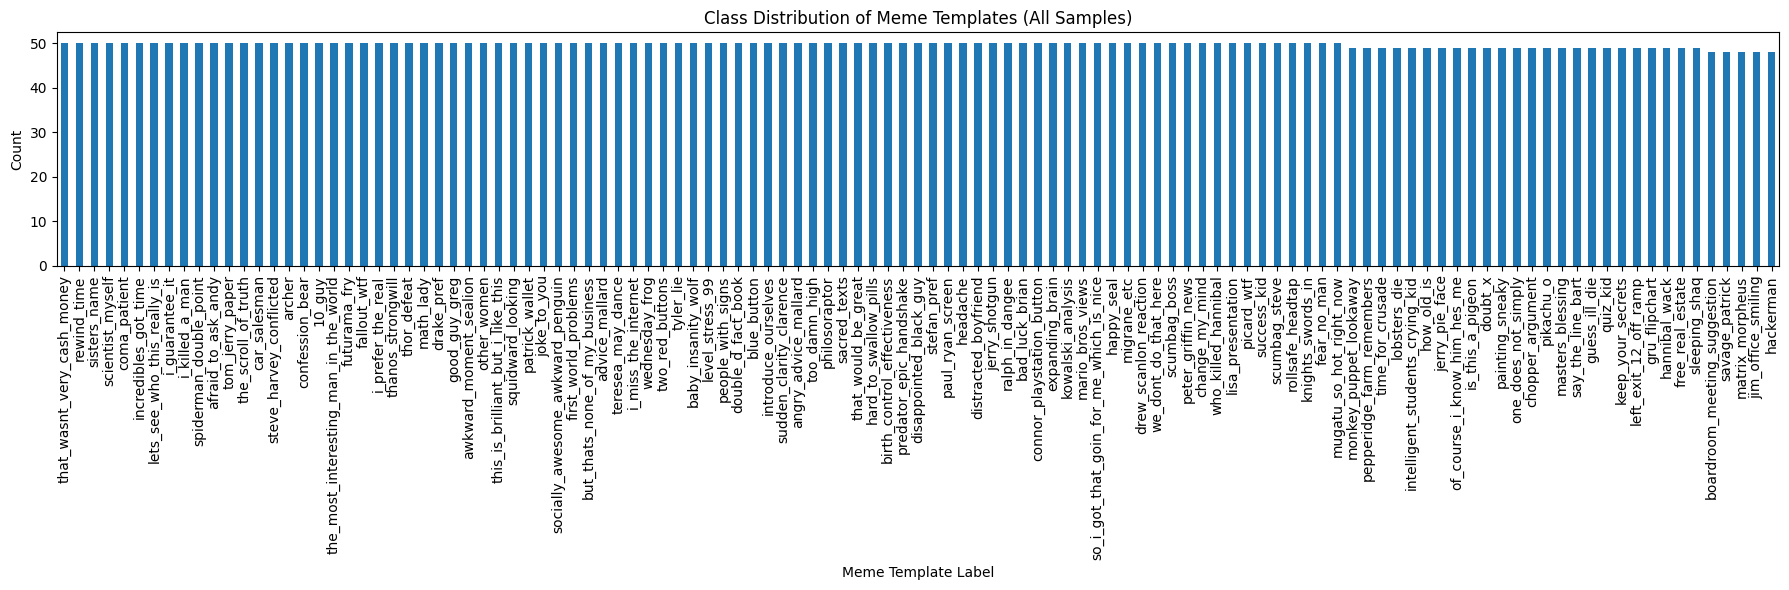

In [ ]:
import matplotlib.pyplot as plt

# Overall class distribution
label_counts = df_pairs["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(18, 6))
label_counts.plot(kind="bar")
plt.title("Class Distribution of Meme Templates (All Samples)")
plt.xlabel("Meme Template Label")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


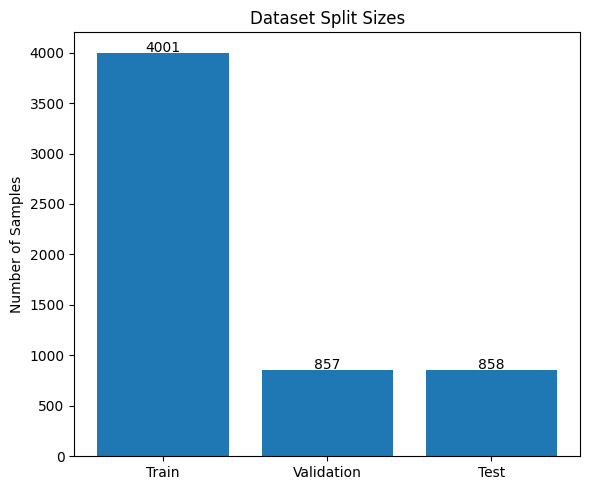

In [ ]:
split_names = ["Train", "Validation", "Test"]
split_counts = [len(train_df), len(val_df), len(test_df)]

plt.figure(figsize=(6, 5))
plt.bar(split_names, split_counts)
plt.title("Dataset Split Sizes")
plt.ylabel("Number of Samples")
for i, v in enumerate(split_counts):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()


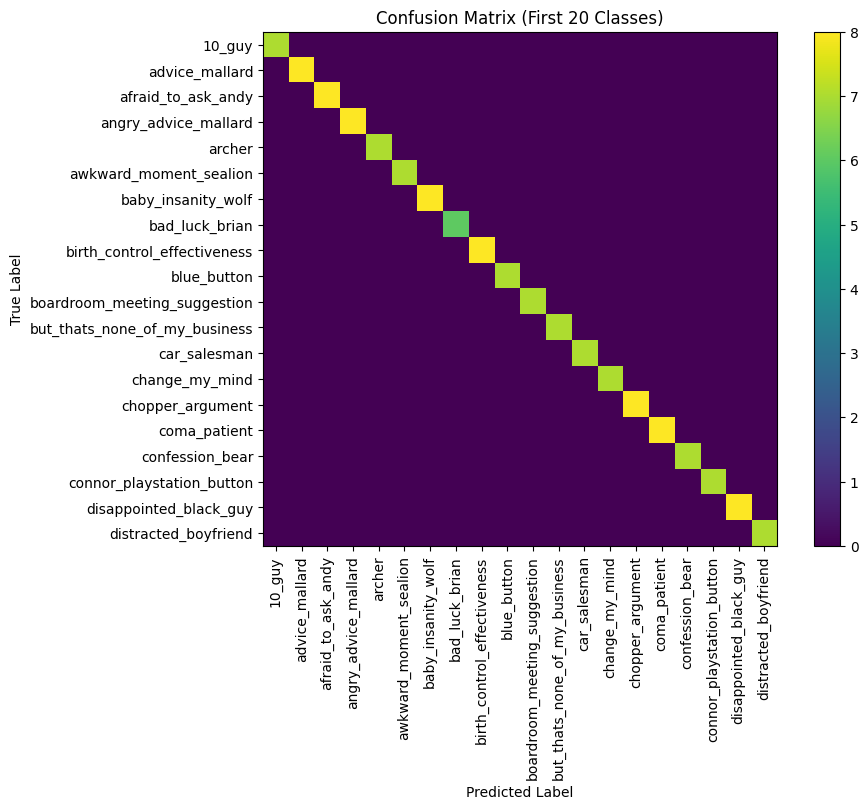

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# pick first N classes for visualization
N = 20
subset_labels = [id_to_label[i] for i in range(min(N, len(id_to_label)))]

subset_indices = [label_to_id[lbl] for lbl in subset_labels]

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=subset_indices
)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title(f"Confusion Matrix (First {len(subset_labels)} Classes)")
plt.colorbar()
tick_marks = np.arange(len(subset_labels))
plt.xticks(tick_marks, subset_labels, rotation=90)
plt.yticks(tick_marks, subset_labels)
plt.tight_layout()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


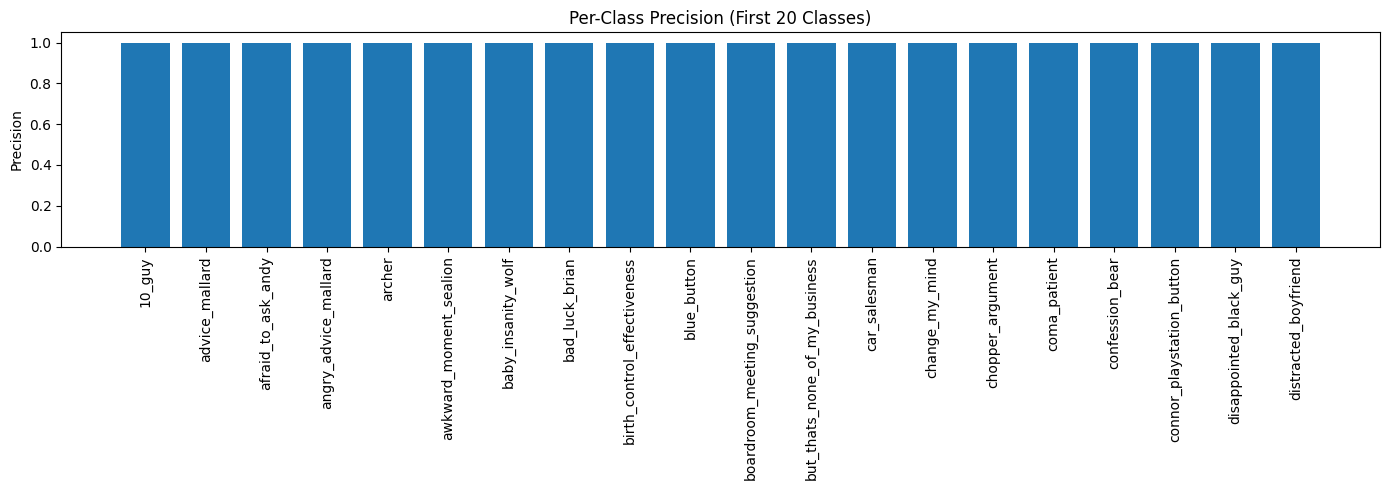

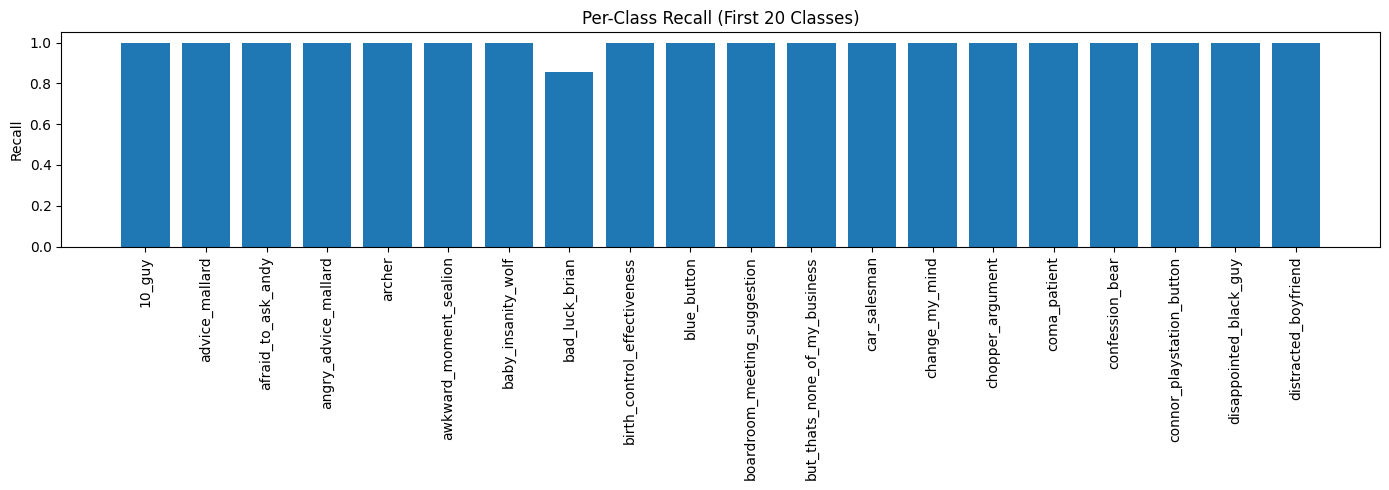

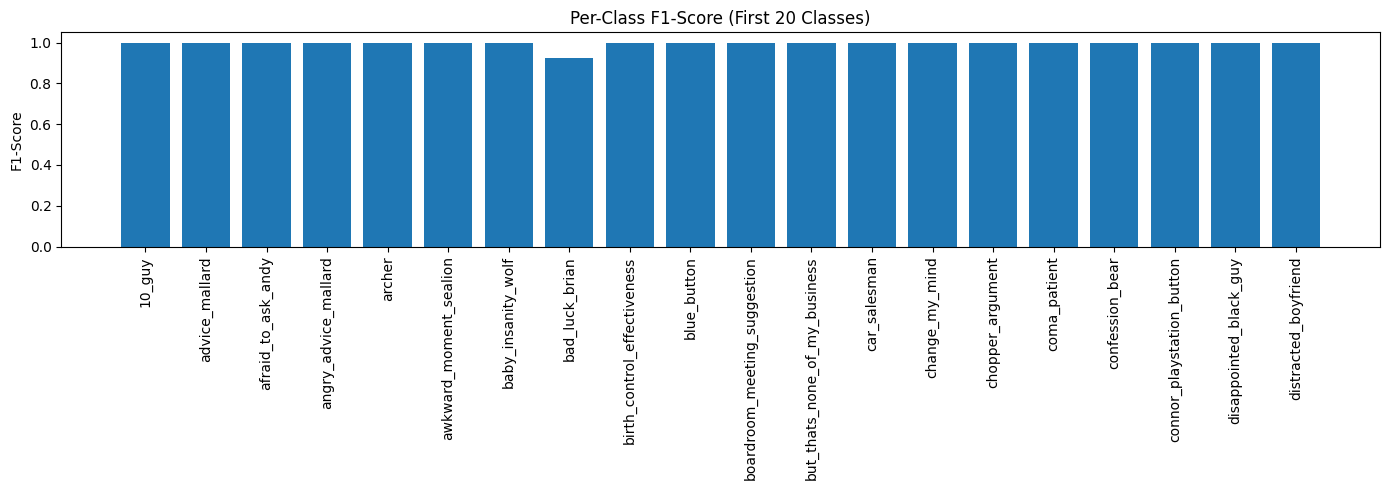

In [ ]:
from sklearn.metrics import classification_report

target_names = [id_to_label[i] for i in range(len(id_to_label))]

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=target_names,
    output_dict=True
)

# Collect per-class metrics
class_metrics = []
for cls_name in target_names:
    metrics = report_dict.get(cls_name, None)
    if metrics:
        class_metrics.append({
            "label": cls_name,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1-score"],
            "support": metrics["support"],
        })

metrics_df = pd.DataFrame(class_metrics)

# Take first N classes for display
N = 20
top_metrics = metrics_df.head(N)

plt.figure(figsize=(14, 5))
plt.bar(top_metrics["label"], top_metrics["precision"])
plt.title("Per-Class Precision (First 20 Classes)")
plt.xticks(rotation=90)
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(top_metrics["label"], top_metrics["recall"])
plt.title("Per-Class Recall (First 20 Classes)")
plt.xticks(rotation=90)
plt.ylabel("Recall")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.bar(top_metrics["label"], top_metrics["f1"])
plt.title("Per-Class F1-Score (First 20 Classes)")
plt.xticks(rotation=90)
plt.ylabel("F1-Score")
plt.tight_layout()
plt.show()


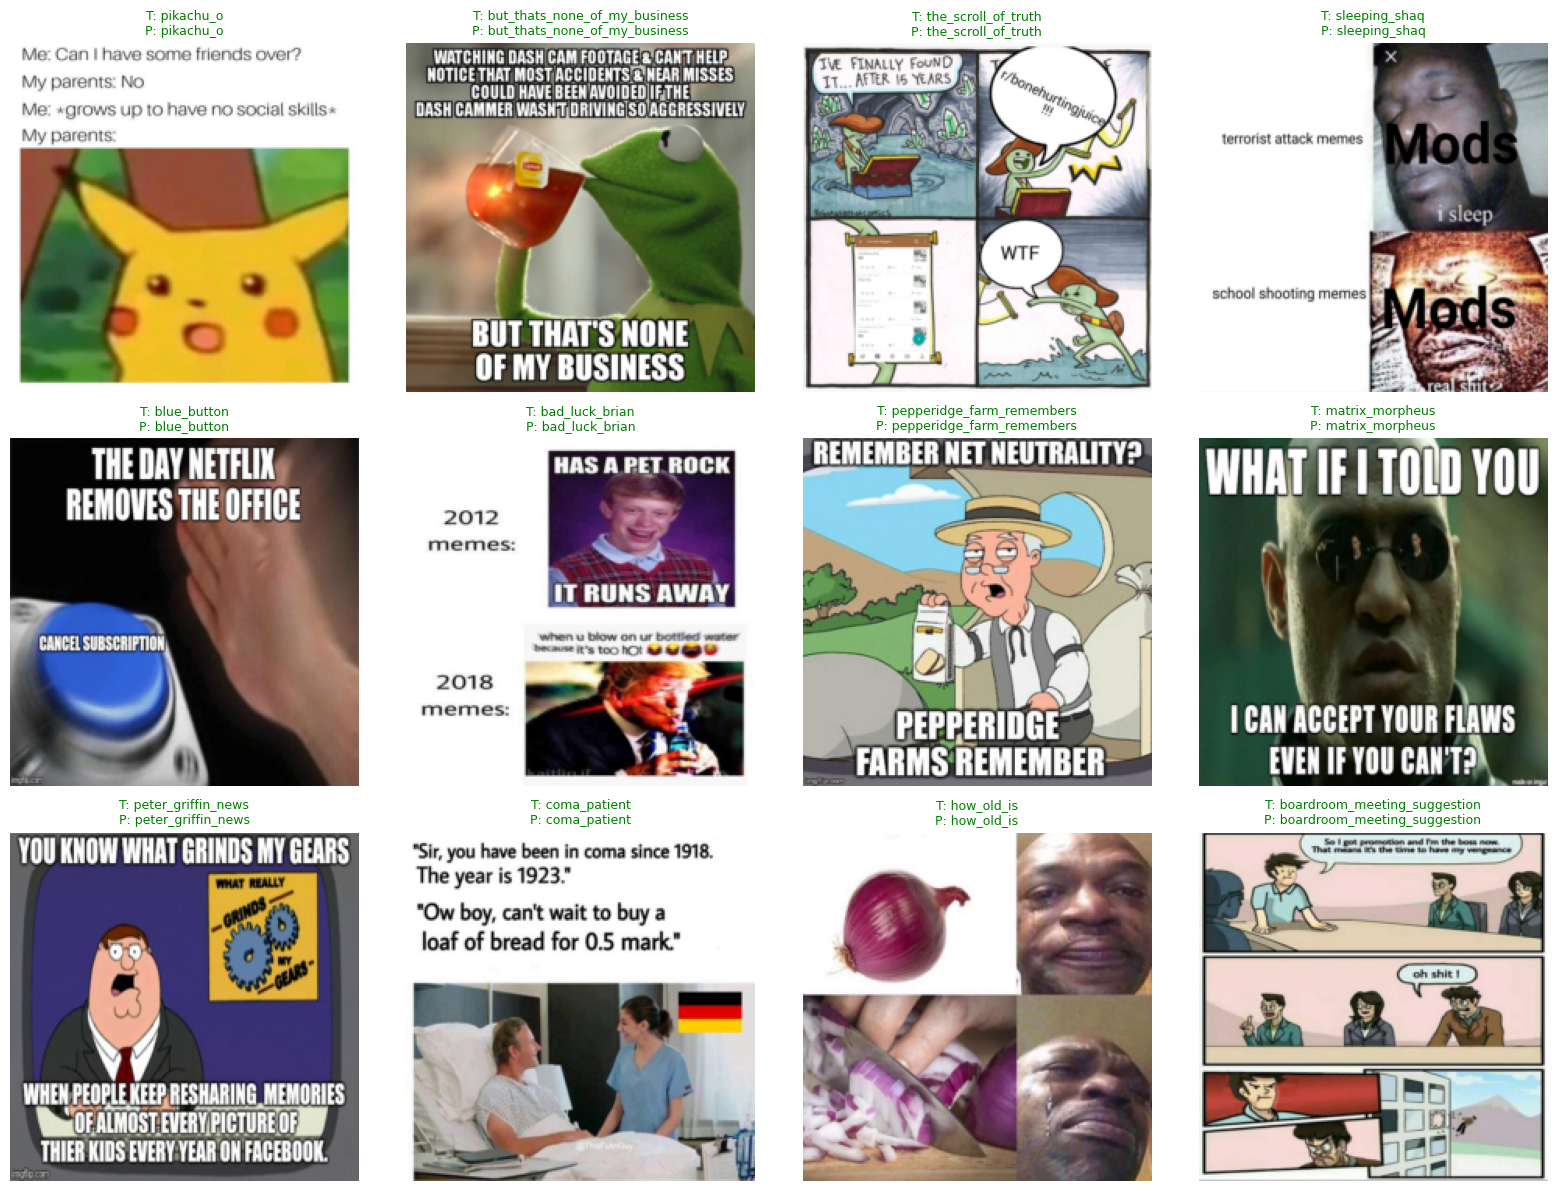

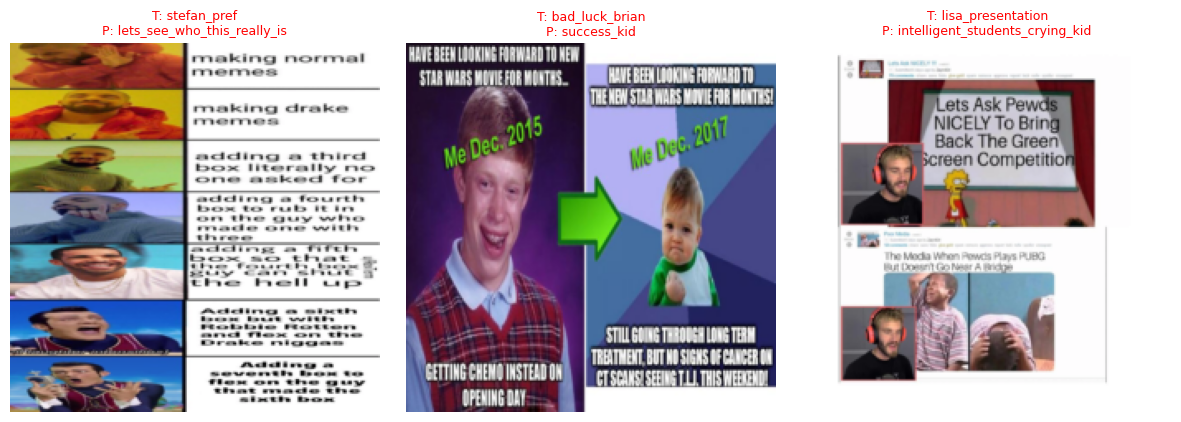

In [ ]:
import random
from torchvision.transforms.functional import to_pil_image

# Build a list of (image_tensor, true_label_id, pred_label_id)
model.eval()
sample_records = []

with torch.no_grad():
    for i, (imgs, lbls) in enumerate(test_loader):
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)
        logits = model(imgs)
        preds = logits.argmax(1)

        for img_tensor, true_id, pred_id in zip(imgs, lbls, preds):
            sample_records.append((img_tensor.cpu(), int(true_id.cpu()), int(pred_id.cpu())))

# Shuffle for randomness
random.shuffle(sample_records)

def show_samples(records, n_rows=3, n_cols=4, only_misclassified=False):
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))
    shown = 0
    idx = 0

    while shown < n_rows * n_cols and idx < len(records):
        img_tensor, true_id, pred_id = records[idx]
        idx += 1

        if only_misclassified and true_id == pred_id:
            continue

        plt.subplot(n_rows, n_cols, shown + 1)
        # tensor is normalized; unnormalize roughly
        img = img_tensor.clone()
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img = img + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        img = torch.clamp(img, 0, 1)

        plt.imshow(to_pil_image(img))
        true_label = id_to_label[true_id]
        pred_label = id_to_label[pred_id]
        color = "green" if true_id == pred_id else "red"
        plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=9)
        plt.axis("off")
        shown += 1

    plt.tight_layout()
    plt.show()

# ✅ Show a mix of correct + incorrect samples
show_samples(sample_records, n_rows=3, n_cols=4, only_misclassified=False)

# ✅ Show only misclassified samples (if any)
show_samples(sample_records, n_rows=3, n_cols=4, only_misclassified=True)
